# **Project Title : Internship Project -  Skin Disorder Prediction**

##  Project Team Id , Project Id and Deadlines

- **Project Team ID** : 
- **Project ID** : PRCP-1027-Skin Disorder Prediction
- **Institute** : DataMites

# **Business Case and Details**

## **Business Case: Skin Disorder Prediction**

Skin disorders like psoriasis, seborrheic dermatitis, lichen planus, pityriasis rosea, chronic dermatitis, and pityriasis rubra pilaris share overlapping clinical symptoms such as erythema and scaling. These similarities often lead to diagnostic challenges, especially in the early stages when the disease may mimic others.

Traditionally, diagnosis requires:
* Clinical examination
* Histopathological evaluation via biopsy
* Expert medical judgment

However, similar visual and microscopic characteristics make accurate diagnosis difficult. A machine learning–based approach helps in:
* Early detection
* Reducing unnecessary biopsies
* Supporting doctors with reliable predictions
* Classifying patients into correct disease categories


## **Dataset Summary**

Total Attributes: 34

* 12 clinical attributes
* 22 histopathological attributes

Target: 6 skin disease classes

Feature values:

* Most attributes take values 0–3 (degree of severity)

* Family history is binary

* Age is continuous

Diagnosis Difficulty:

* Overlapping symptoms and biopsy results
* Diseases evolve and show mixed characteristics at early stages

This project uses these attributes to classify the correct skin disease earliest to doctor.

# Imports and Configurations

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
df

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,2,1,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,2,0,25,4
362,3,2,1,0,1,0,0,0,0,0,...,1,0,1,0,0,0,2,0,36,4
363,3,2,2,2,3,2,0,2,0,0,...,0,3,0,3,0,0,2,3,28,3
364,2,1,3,1,2,3,0,2,0,0,...,0,2,0,1,0,0,2,3,50,3


# Domain Analysis

1. **erythema** – Redness of the skin caused by increased blood flow, common in inflammatory skin diseases.


2. **scaling** – Flaking or shedding of the outer skin layer, typical in psoriasis and dermatitis.


3. **definite_borders** – Clearly demarcated lesion edges, often seen in psoriasis.


4. **itching** – Sensation causing urge to scratch; common in inflammatory and allergic skin conditions.


5. **koebner_phenomenon** – Appearance of lesions at sites of skin trauma, characteristic of psoriasis.


6. **polygonal_papules** – Flat-topped, multi-sided skin bumps, typical of lichen planus.


7. **follicular_papules** – Papules arising from hair follicles, seen in follicular disorders.


8. **oral_mucosal_involvement** – Lesions affecting mouth mucosa, important in lichen planus diagnosis.


9. **knee_and_elbow_involvement** – Psoriatic lesions commonly appear on these extensor surfaces.


10. **scalp_involvement** – Presence of lesions on scalp, frequent in psoriasis.


11. **family_history** – Genetic predisposition indicator for chronic skin diseases.


12. **melanin_incontinence** – Leakage of melanin into dermis due to basal layer damage.


13. **eosinophils_in_the_infiltrate** – Presence of eosinophils indicating allergic or inflammatory response.


14. **PNL_infiltrate** – Polymorphonuclear leukocyte infiltration, marker of acute inflammation.


15. **fibrosis_of_the_papillary_dermis** – Thickening/scarring of upper dermis due to chronic inflammation.


16. **exocytosis** – Migration of inflammatory cells into the epidermis.


17. **acanthosis** – Thickening of the epidermal layer, common in chronic skin conditions.


18. **hyperkeratosis** – Excessive thickening of the stratum corneum (outer skin layer).


19. **parakeratosis** – Retention of nuclei in stratum corneum, hallmark of psoriasis.


20. **clubbing_of_the_rete_ridges** – Bulbous elongation of epidermal ridges, seen in psoriasis.


21. **elongation_of_the_rete_ridges** – Downward growth of epidermal projections into dermis.


22. **thinning_of_the_suprapapillary_epidermis** – Reduced epidermal thickness above dermal papillae.


23. **spongiform_pustule** – Pus-filled spaces within epidermis, typical of pustular psoriasis.


24. **munro_microabcess** – Neutrophil collections in stratum corneum, classic psoriasis feature.


25. **focal_hypergranulosis** – Localized thickening of granular layer, seen in lichen planus.


26. **disappearance_of_the_granular_layer** – Loss of granular layer, common in psoriasis.


27. **vacuolisation_and_damage_of_basal_layer** – Degeneration of basal cells, seen in lichenoid disorders.


28. **spongiosis** – Intercellular edema in epidermis, characteristic of eczema.


39. **saw-tooth_appearance_of_retes** – Irregular pointed rete ridges, classic sign of lichen planus.


30. **follicular_horn_plug** – Keratin plug blocking hair follicle opening.


31. **perifollicular_parakeratosis** – Parakeratosis around hair follicles.


32. **inflammatory_monoluclear_inflitrate** – Lymphocyte-dominated chronic inflammatory infiltrate.


33. **band-like_infiltrate** – Dense horizontal inflammatory cell band, typical of lichen planus.


34. **Age** – Patient’s age, important for disease prevalence and progression patterns.


35. **class** – Target variable representing the diagnosed skin disease category.

# Basick Checks

In [4]:
df.head()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   erythema                                  366 non-null    int64 
 1   scaling                                   366 non-null    int64 
 2   definite_borders                          366 non-null    int64 
 3   itching                                   366 non-null    int64 
 4   koebner_phenomenon                        366 non-null    int64 
 5   polygonal_papules                         366 non-null    int64 
 6   follicular_papules                        366 non-null    int64 
 7   oral_mucosal_involvement                  366 non-null    int64 
 8   knee_and_elbow_involvement                366 non-null    int64 
 9   scalp_involvement                         366 non-null    int64 
 10  family_history                            366 non-

In [6]:
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [7]:
df.describe(include='O')

,Age
count,366
unique,61
top,40
freq,17


In [8]:
df['class'].unique()

array([2, 1, 3, 5, 4, 6])

In [9]:
df[df['Age'] == '?']

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
33,2,2,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,?,1
34,2,1,0,0,2,0,0,0,0,0,...,0,0,0,0,0,0,0,0,?,4
35,2,2,1,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,?,2
36,2,1,2,3,2,3,0,2,0,0,...,0,2,0,2,0,0,0,3,?,3
262,2,1,0,2,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,?,5
263,1,1,1,3,0,0,0,0,0,0,...,0,0,3,0,0,0,2,0,?,5
264,1,1,0,2,0,0,0,0,1,0,...,0,0,2,0,0,0,3,0,?,5
265,1,1,0,3,0,0,0,0,0,0,...,0,0,2,0,0,0,3,0,?,5


In [10]:
df['Age'] = df['Age'].replace("?", 9)
# now temporary we replace age with 9(minimum value) because we will replace with median so due to this change not any effect on median so it is good way.

In [11]:
df['Age'] = df['Age'].astype('int64')

In [12]:
df['Age'] = df['Age'].replace(0, df['Age'].median())

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 35 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   erythema                                  366 non-null    int64
 1   scaling                                   366 non-null    int64
 2   definite_borders                          366 non-null    int64
 3   itching                                   366 non-null    int64
 4   koebner_phenomenon                        366 non-null    int64
 5   polygonal_papules                         366 non-null    int64
 6   follicular_papules                        366 non-null    int64
 7   oral_mucosal_involvement                  366 non-null    int64
 8   knee_and_elbow_involvement                366 non-null    int64
 9   scalp_involvement                         366 non-null    int64
 10  family_history                            366 non-null    int6

In [14]:
df.shape

(366, 35)

# EDA - Exploratory Data Analysis

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

In [16]:
num_cols

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

## UniVariate Analysis 

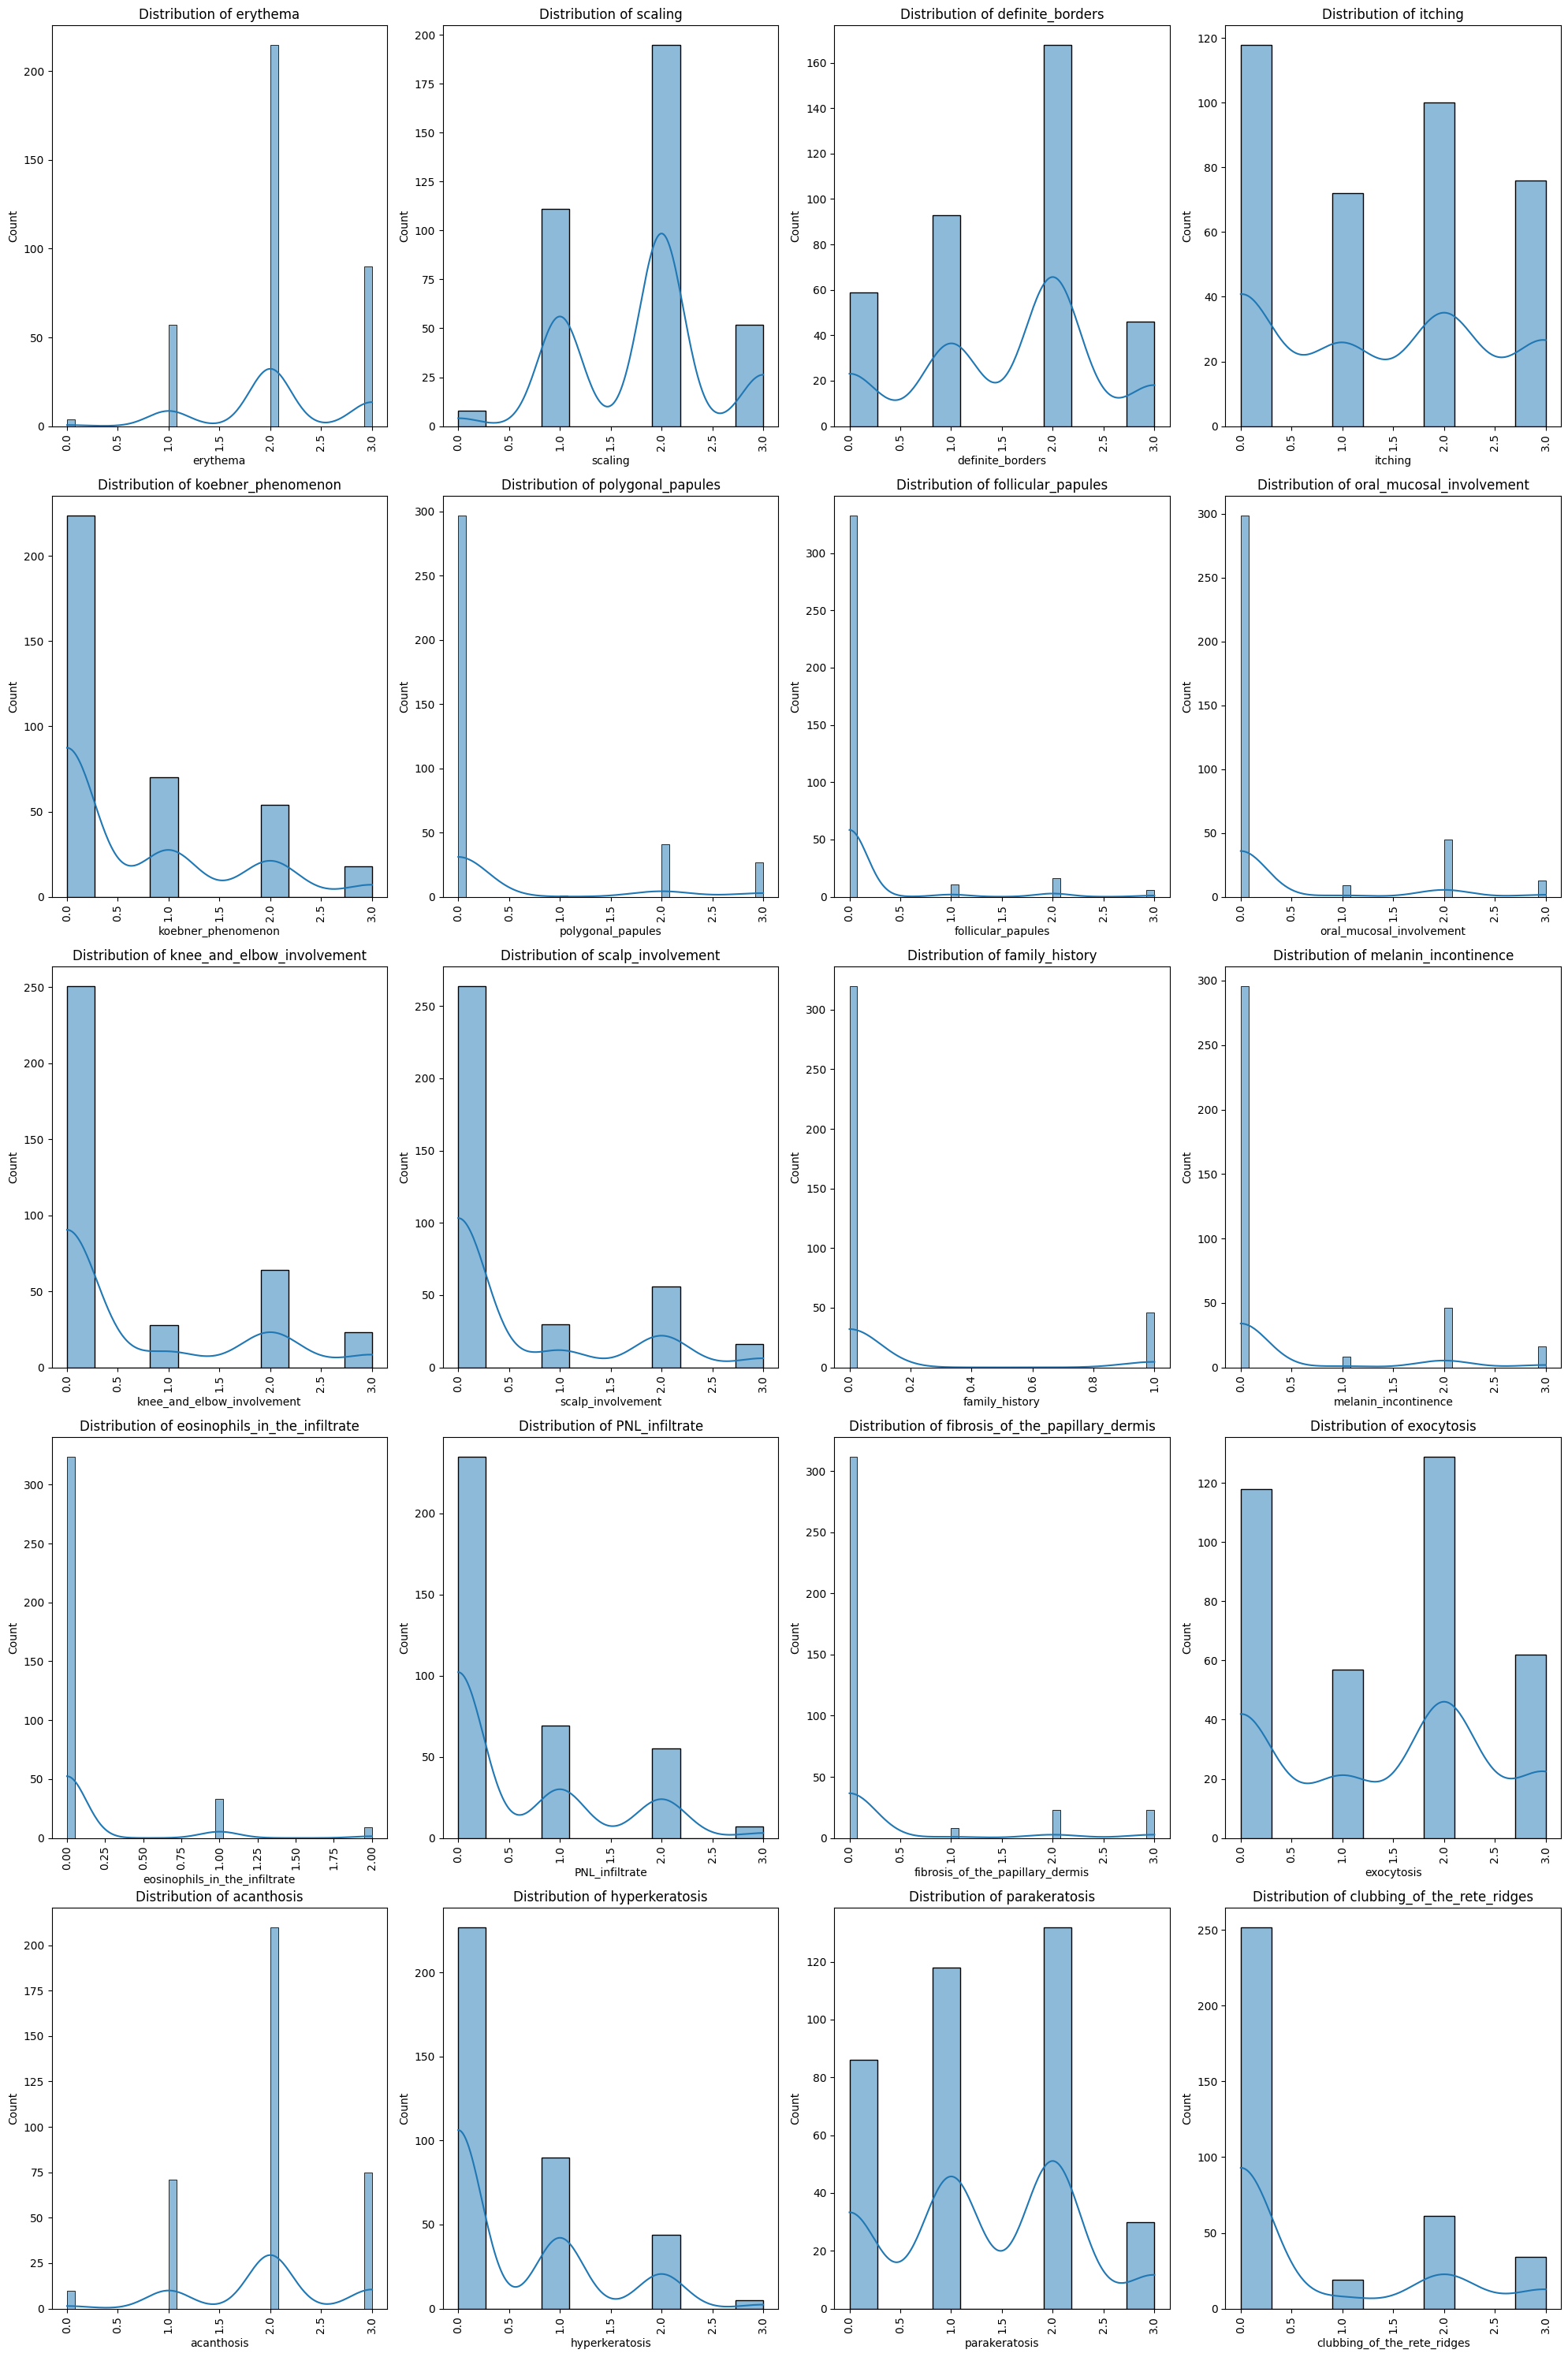

In [17]:
plt.figure(figsize=(20,30))
plot = 1

for i in num_cols:
    if plot <= 20:
        plt.subplot(5, 4, plot)
        sns.histplot(x=df[i], kde=True)
        plt.title(f'Distribution of {i}')
        plt.xticks(rotation=90)
        plot += 1
        
plt.tight_layout()
plt.show()

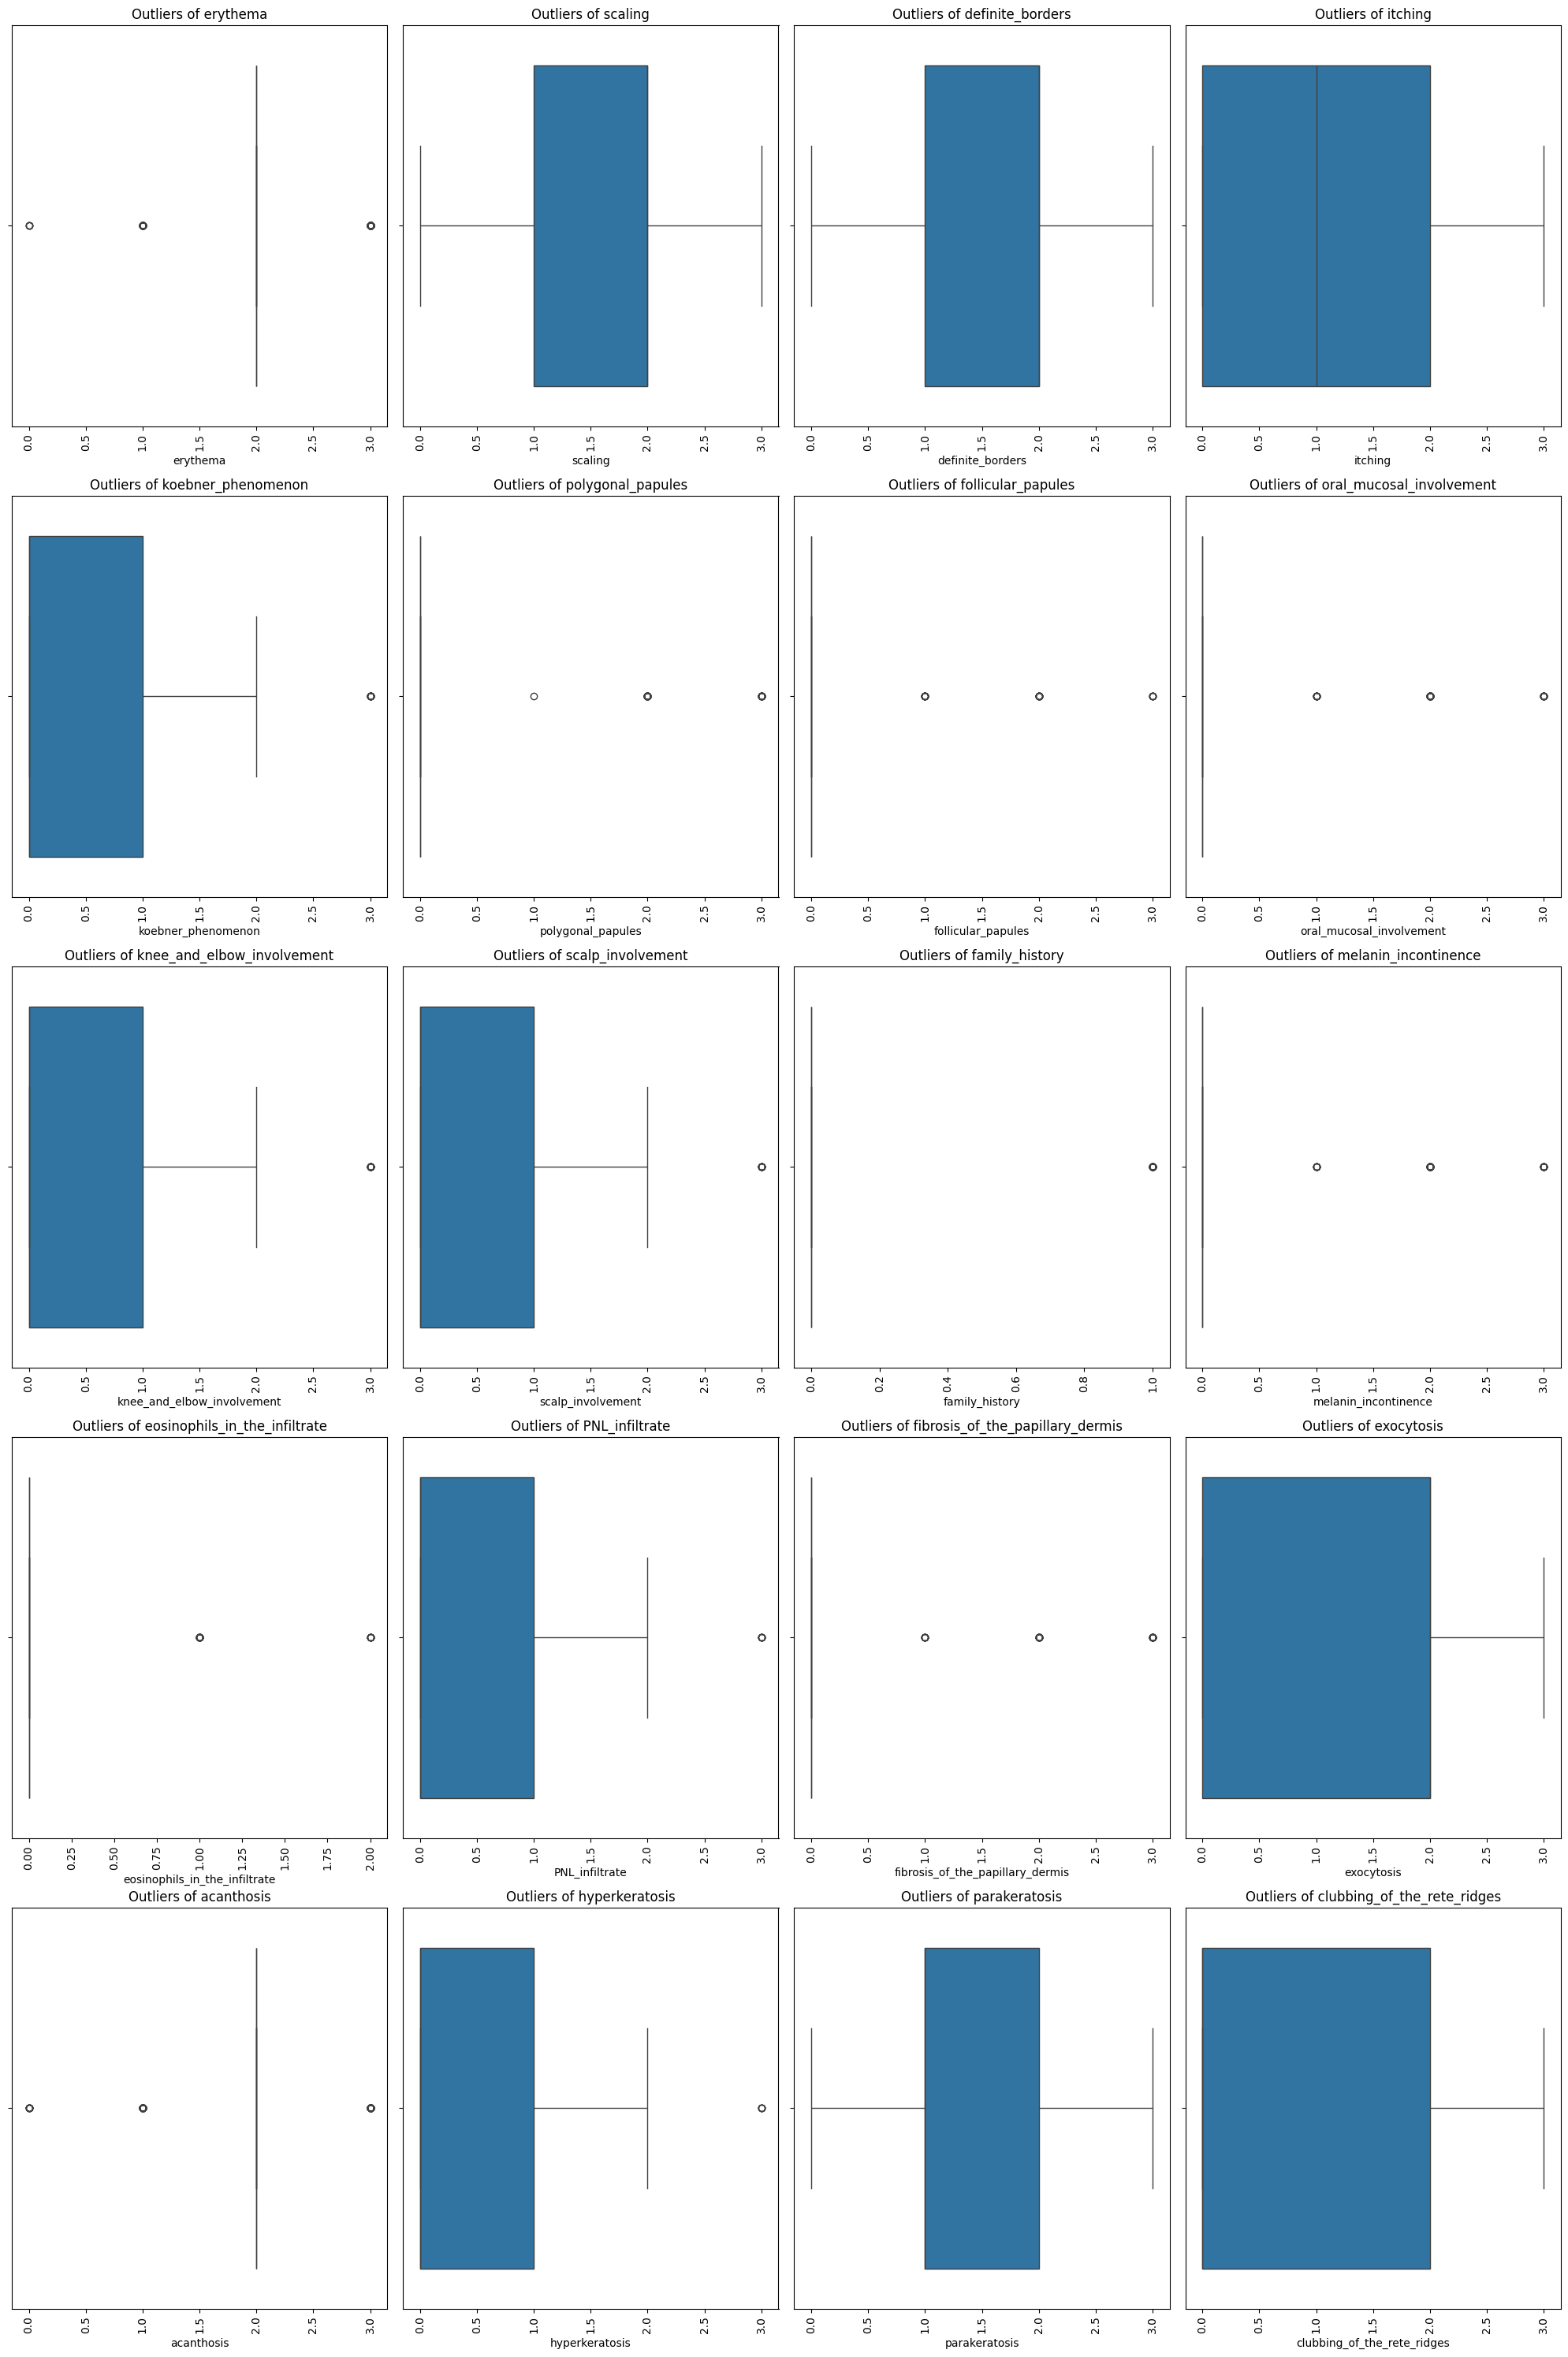

In [18]:
plt.figure(figsize=(20, 30))
plot = 1

for i in num_cols:   
    if plot <= 20:
        plt.subplot(5 ,4, plot)
        sns.boxplot(x=df[i])   
        plt.title(f"Outliers of {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

## Multivariant Analysis

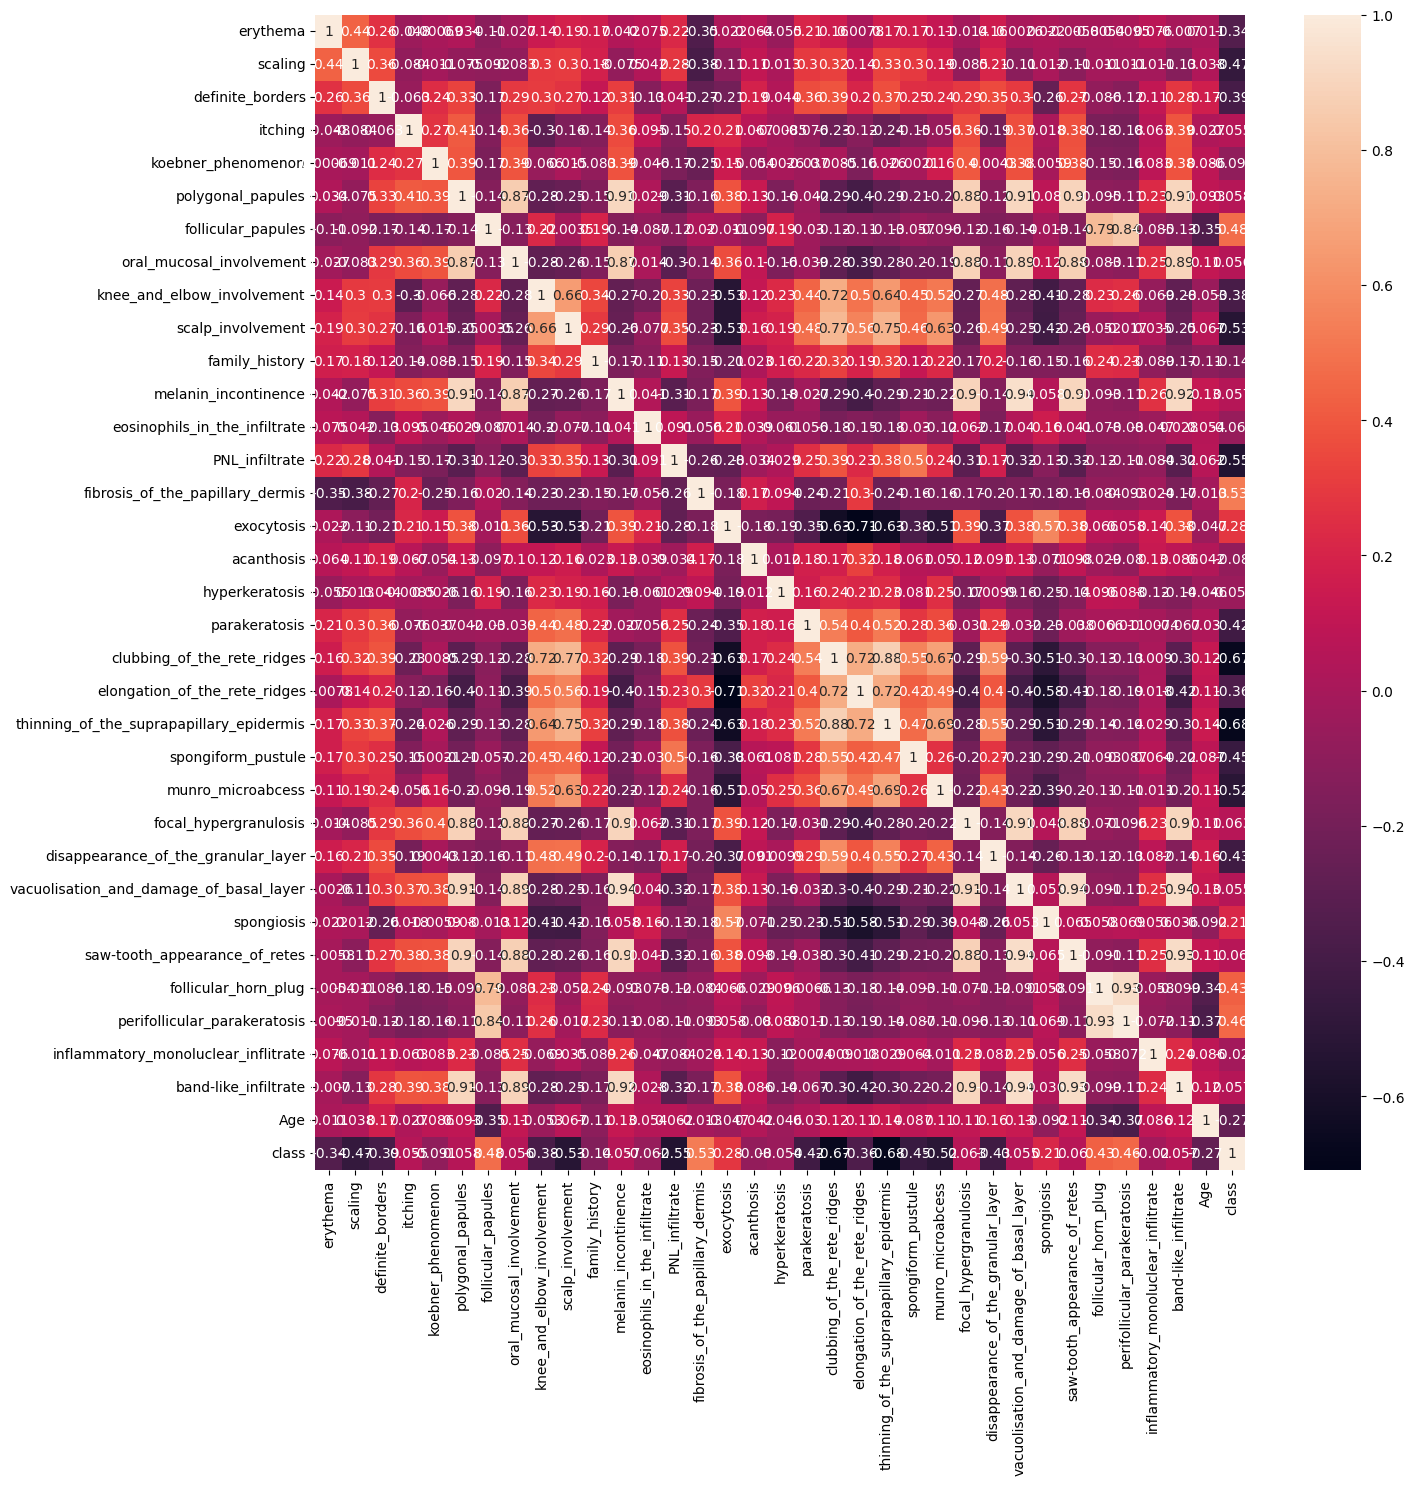

In [21]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(15,15))
sns.heatmap(corr, annot=True)
plt.show()

# Feature engineering 

## Null Value Handling

In [22]:
df.isnull().sum()

erythema                                    0
scaling                                     0
definite_borders                            0
itching                                     0
koebner_phenomenon                          0
polygonal_papules                           0
follicular_papules                          0
oral_mucosal_involvement                    0
knee_and_elbow_involvement                  0
scalp_involvement                           0
family_history                              0
melanin_incontinence                        0
eosinophils_in_the_infiltrate               0
PNL_infiltrate                              0
fibrosis_of_the_papillary_dermis            0
exocytosis                                  0
acanthosis                                  0
hyperkeratosis                              0
parakeratosis                               0
clubbing_of_the_rete_ridges                 0
elongation_of_the_rete_ridges               0
thinning_of_the_suprapapillary_epi

##  Outliers Handling

In [25]:
num_cols

Index(['erythema', 'scaling', 'definite_borders', 'itching',
       'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
       'oral_mucosal_involvement', 'knee_and_elbow_involvement',
       'scalp_involvement', 'family_history', 'melanin_incontinence',
       'eosinophils_in_the_infiltrate', 'PNL_infiltrate',
       'fibrosis_of_the_papillary_dermis', 'exocytosis', 'acanthosis',
       'hyperkeratosis', 'parakeratosis', 'clubbing_of_the_rete_ridges',
       'elongation_of_the_rete_ridges',
       'thinning_of_the_suprapapillary_epidermis', 'spongiform_pustule',
       'munro_microabcess', 'focal_hypergranulosis',
       'disappearance_of_the_granular_layer',
       'vacuolisation_and_damage_of_basal_layer', 'spongiosis',
       'saw-tooth_appearance_of_retes', 'follicular_horn_plug',
       'perifollicular_parakeratosis', 'inflammatory_monoluclear_inflitrate',
       'band-like_infiltrate', 'Age', 'class'],
      dtype='object')

In [27]:
num_cols = num_cols.drop('class')

In [28]:
for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
        
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
        
    outliers_upper = df[df[i] > upper_bound]
    outliers_lower = df[df[i] < lower_bound]
    print(f"{i} -Upper outliers: {outliers_upper.shape}, Lower outliers: {outliers_lower.shape}")
        
    # Cap outliers using .loc
    df.loc[df[i] > upper_bound, i] = upper_bound
    df.loc[df[i] < lower_bound, i] = lower_bound

erythema -Upper outliers: (90, 35), Lower outliers: (61, 35)
scaling -Upper outliers: (0, 35), Lower outliers: (0, 35)
definite_borders -Upper outliers: (0, 35), Lower outliers: (0, 35)
itching -Upper outliers: (0, 35), Lower outliers: (0, 35)
koebner_phenomenon -Upper outliers: (18, 35), Lower outliers: (0, 35)
polygonal_papules -Upper outliers: (69, 35), Lower outliers: (0, 35)
follicular_papules -Upper outliers: (33, 35), Lower outliers: (0, 35)
oral_mucosal_involvement -Upper outliers: (67, 35), Lower outliers: (0, 35)
knee_and_elbow_involvement -Upper outliers: (23, 35), Lower outliers: (0, 35)
scalp_involvement -Upper outliers: (16, 35), Lower outliers: (0, 35)
family_history -Upper outliers: (46, 35), Lower outliers: (0, 35)
melanin_incontinence -Upper outliers: (70, 35), Lower outliers: (0, 35)
eosinophils_in_the_infiltrate -Upper outliers: (42, 35), Lower outliers: (0, 35)
PNL_infiltrate -Upper outliers: (7, 35), Lower outliers: (0, 35)
fibrosis_of_the_papillary_dermis -Upper 

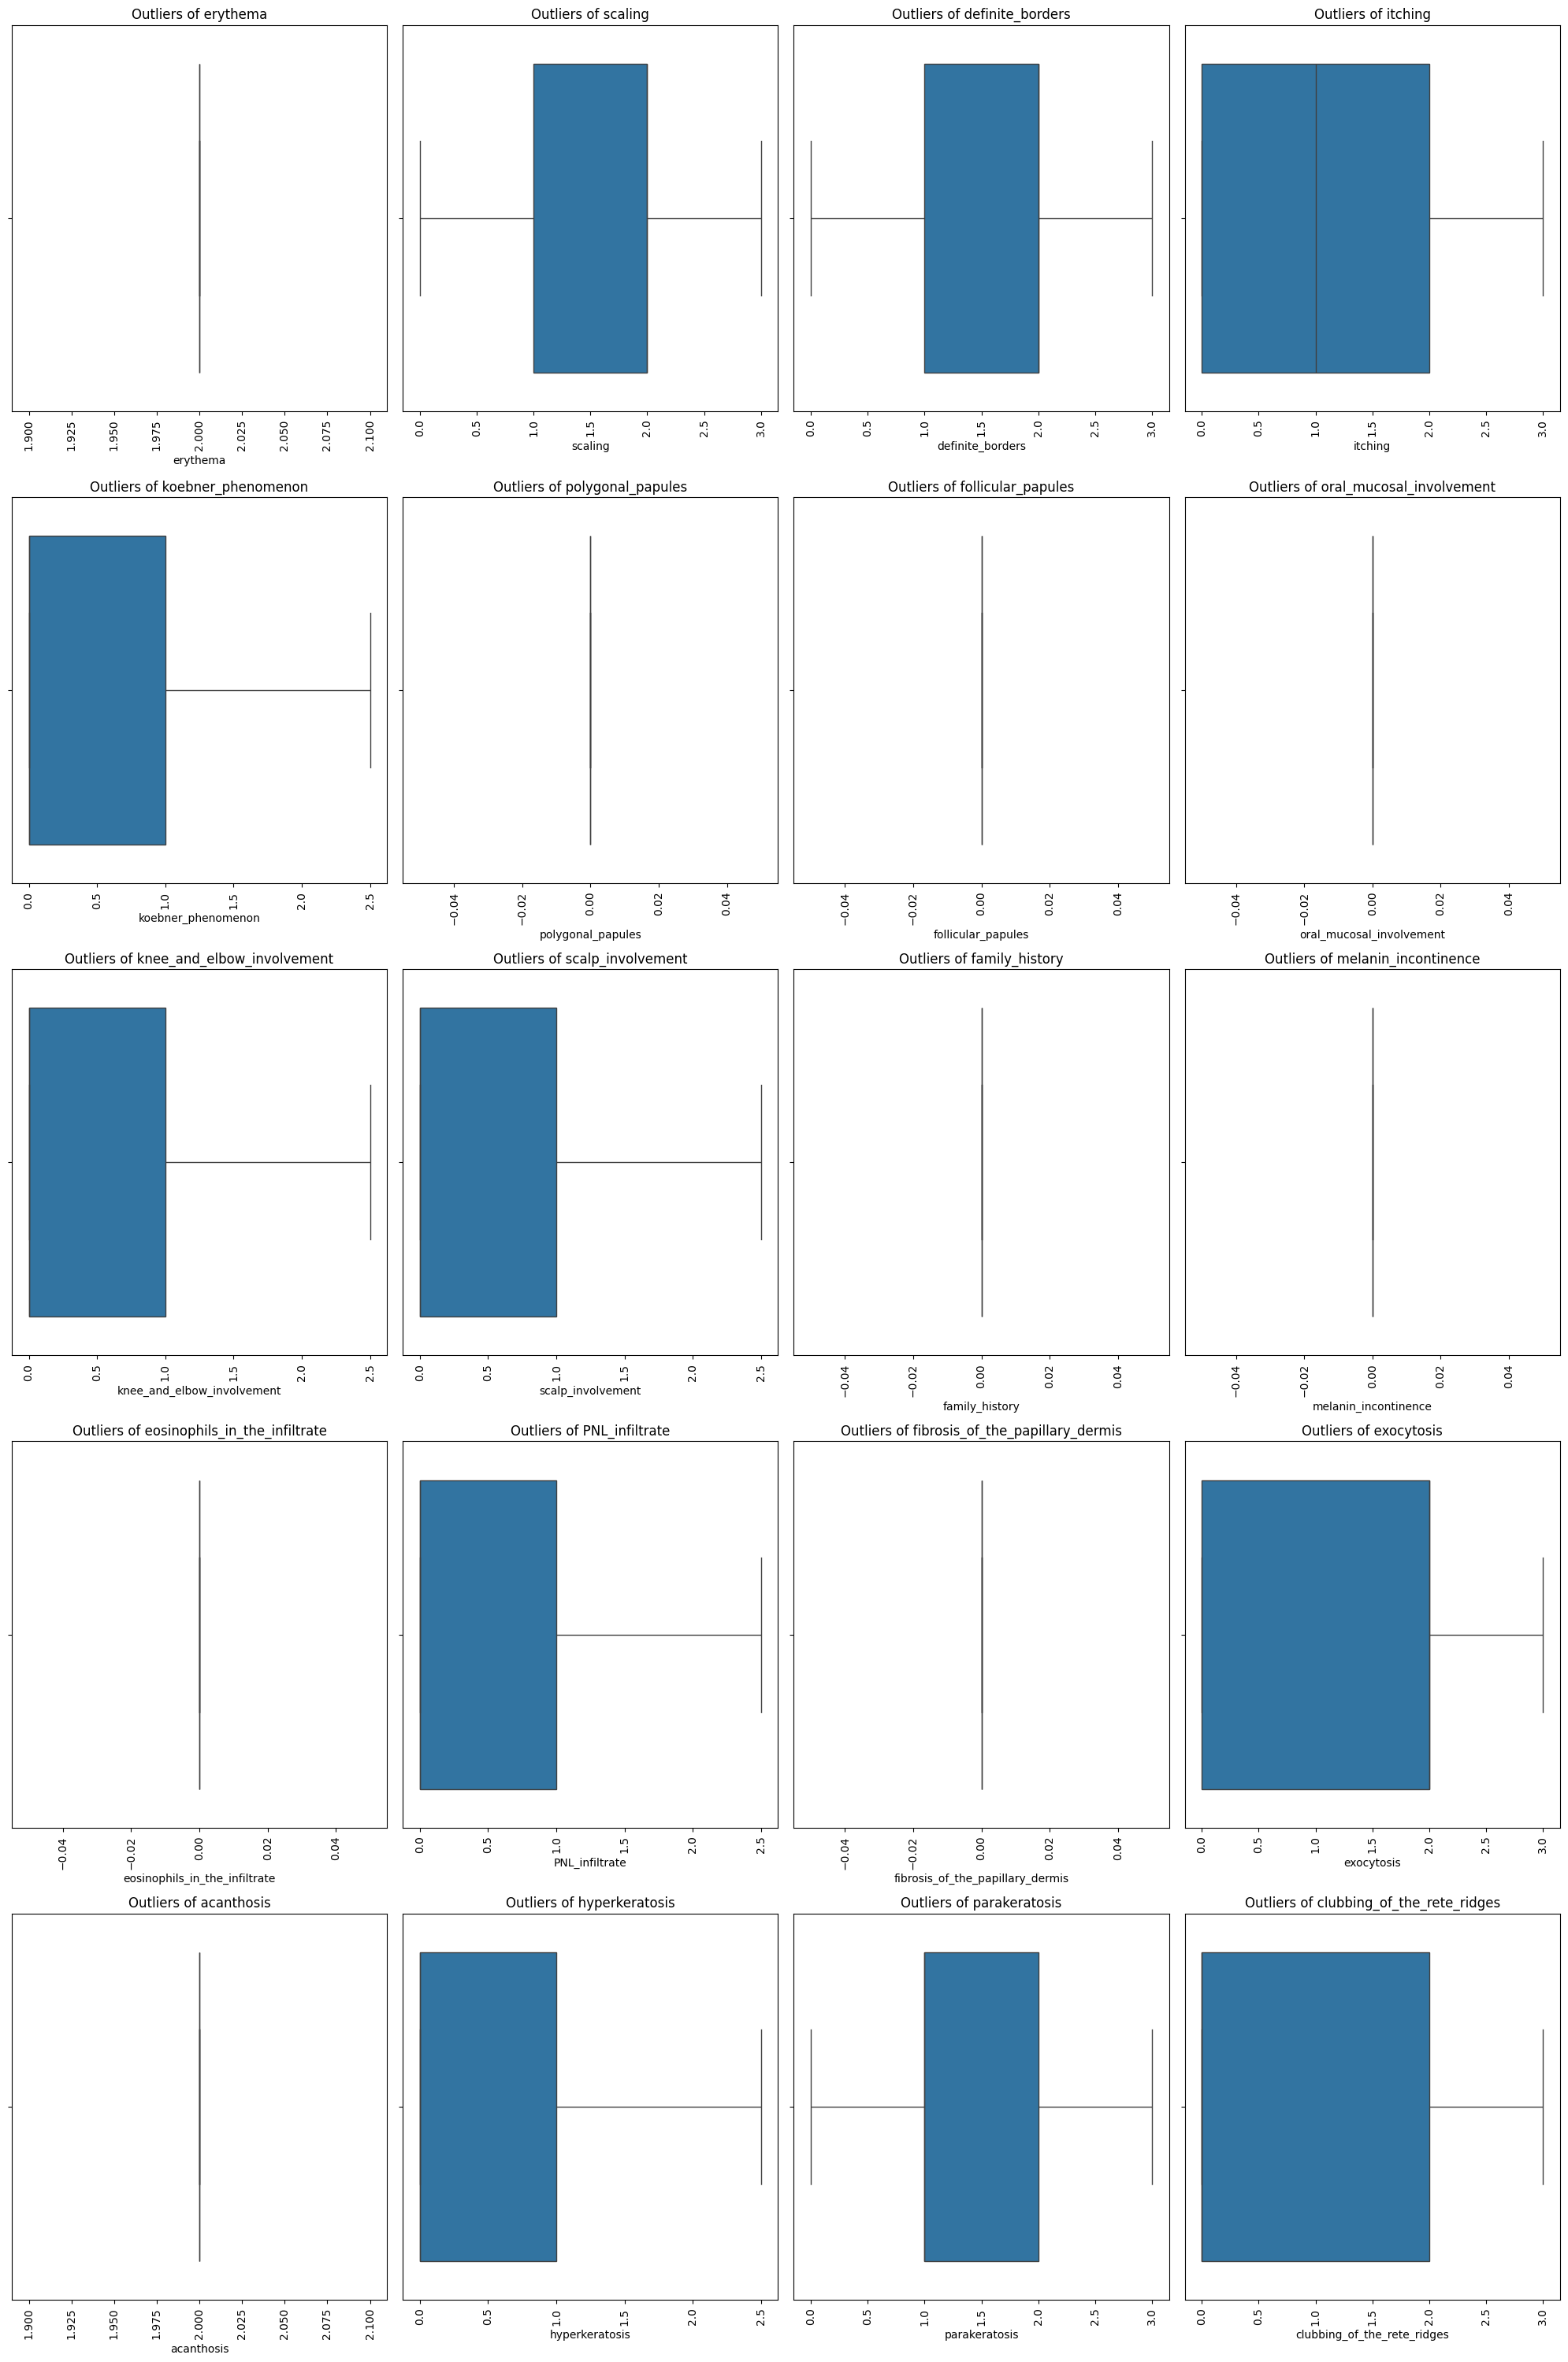

In [29]:
plt.figure(figsize=(20, 30))
plot = 1

for i in num_cols:   
    if plot <= 20:
        plt.subplot(5 ,4, plot)
        sns.boxplot(x=df[i])   
        plt.title(f"Outliers of {i}")
        plt.xticks(rotation=90)       
        plot += 1

plt.tight_layout()
plt.show()

## Feature Selection

In [32]:
corr_matrix = df.corr()

In [33]:
corr_matrix

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_of_the_granular_layer,vacuolisation_and_damage_of_basal_layer,spongiosis,saw-tooth_appearance_of_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_monoluclear_inflitrate,band-like_infiltrate,Age,class
erythema,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scaling,NaN,1.000000,0.357987,-0.084197,-0.019812,NaN,NaN,NaN,0.305298,0.307019,...,0.215847,NaN,0.012151,NaN,NaN,NaN,-0.010977,NaN,0.038304,-0.468688
definite_borders,NaN,0.357987,1.000000,-0.062564,0.242126,NaN,NaN,NaN,0.298931,0.268433,...,0.356670,NaN,-0.255536,NaN,NaN,NaN,0.111882,NaN,0.167842,-0.391974
itching,NaN,-0.084197,-0.062564,1.000000,0.259215,NaN,NaN,NaN,-0.302805,-0.163263,...,-0.193095,NaN,0.017514,NaN,NaN,NaN,0.062781,NaN,0.026983,0.054772
koebner_phenomenon,NaN,-0.019812,0.242126,0.259215,1.000000,NaN,NaN,NaN,-0.076485,0.006118,...,0.012665,NaN,-0.011837,NaN,NaN,NaN,0.079423,NaN,0.089806,-0.096283
polygonal_papules,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
follicular_papules,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oral_mucosal_involvement,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
knee_and_elbow_involvement,NaN,0.305298,0.298931,-0.302805,-0.076485,NaN,NaN,NaN,1.000000,0.669836,...,0.468670,NaN,-0.416470,NaN,NaN,NaN,-0.067962,NaN,-0.061764,-0.388490
scalp_involvement,NaN,0.307019,0.268433,-0.163263,0.006118,NaN,NaN,NaN,0.669836,1.000000,...,0.491946,NaN,-0.426675,NaN,NaN,NaN,0.032712,NaN,0.077661,-0.539229


### Correlation with target

In [34]:
class_corr = corr_matrix['class'].sort_values(ascending=False)
class_corr

class                                       1.000000
exocytosis                                  0.283433
spongiosis                                  0.213401
itching                                     0.054772
inflammatory_monoluclear_inflitrate        -0.020402
hyperkeratosis                             -0.046607
koebner_phenomenon                         -0.096283
Age                                        -0.273343
elongation_of_the_rete_ridges              -0.357924
knee_and_elbow_involvement                 -0.388490
definite_borders                           -0.391974
parakeratosis                              -0.420742
disappearance_of_the_granular_layer        -0.428313
scaling                                    -0.468688
scalp_involvement                          -0.539229
PNL_infiltrate                             -0.555971
clubbing_of_the_rete_ridges                -0.668781
thinning_of_the_suprapapillary_epidermis   -0.700685
erythema                                      

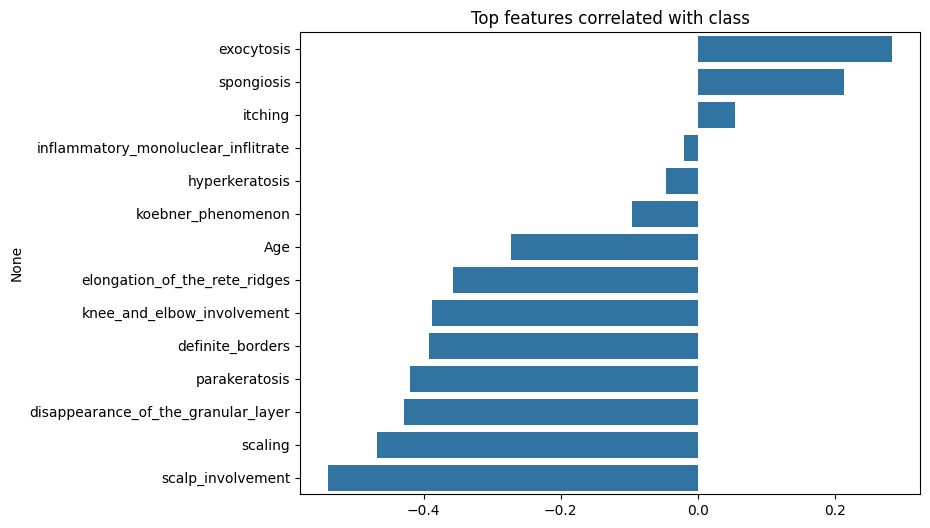

In [35]:
top_corr = class_corr[1:15]

plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top features correlated with class")
plt.show()

In [36]:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.85)
]

high_corr

['thinning_of_the_suprapapillary_epidermis']

### Droping Columns

In [38]:
drop_cols = ['erythema',
'polygonal_papules',
'follicular_papules',
'oral_mucosal_involvement',
'family_history',
'melanin_incontinence',
'eosinophils_in_the_infiltrate',
'fibrosis_of_the_papillary_dermis',
'acanthosis',
'spongiform_pustule',
'munro_microabcess',
'focal_hypergranulosis',
'vacuolisation_and_damage_of_basal_layer',
'saw-tooth_appearance_of_retes',
'follicular_horn_plug',
'perifollicular_parakeratosis',
'band-like_infiltrate']
df = df.drop(columns=drop_cols)

# Modeling 

In [48]:
from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['class'])
y = df['class']

vt = VarianceThreshold(threshold=0)
X_vt = vt.fit_transform(X)

kept_features = X.columns[vt.get_support()]
removed_features = X.columns[~vt.get_support()]

print("Removed columns:", removed_features.tolist())

X = X[kept_features]

Removed columns: []


In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

## Logistic Regression

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Scaling (only for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9594594594594594
[[23  0  0  0  0  0]
 [ 0 11  0  1  0  0]
 [ 0  0 15  0  0  0]
 [ 0  1  1  8  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.92      0.92      0.92        12
           3       0.94      1.00      0.97        15
           4       0.89      0.80      0.84        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00         4

    accuracy                           0.96        74
   macro avg       0.96      0.95      0.95        74
weighted avg       0.96      0.96      0.96        74



## RandomForest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9324324324324325
[[23  0  0  0  0  0]
 [ 0 10  0  1  1  0]
 [ 0  2 13  0  0  0]
 [ 0  1  0  9  0  0]
 [ 0  0  0  0 10  0]
 [ 0  0  0  0  0  4]]
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       0.77      0.83      0.80        12
           3       1.00      0.87      0.93        15
           4       0.90      0.90      0.90        10
           5       0.91      1.00      0.95        10
           6       1.00      1.00      1.00         4

    accuracy                           0.93        74
   macro avg       0.93      0.93      0.93        74
weighted avg       0.94      0.93      0.93        74



## Compare Accuracy

In [54]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.959459
1,Random Forest,0.932432


## Confusion Matrix

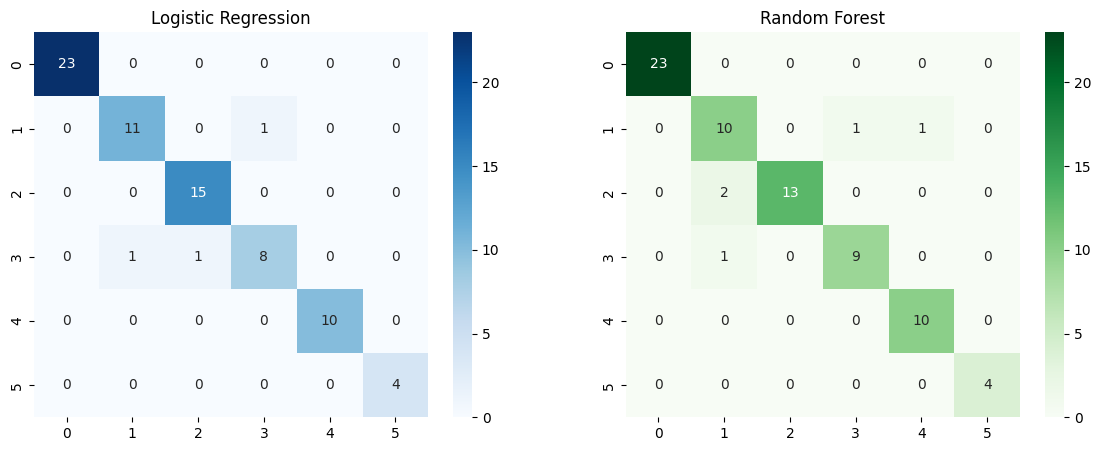

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest")

plt.show()

## Feature Importance
-  Random Forest Feature Importance

In [56]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

clubbing_of_the_rete_ridges                 0.108662
elongation_of_the_rete_ridges               0.107464
thinning_of_the_suprapapillary_epidermis    0.092503
spongiosis                                  0.082845
koebner_phenomenon                          0.079792
PNL_infiltrate                              0.073288
itching                                     0.066991
Age                                         0.066569
definite_borders                            0.057893
exocytosis                                  0.055534
dtype: float64

### Plot

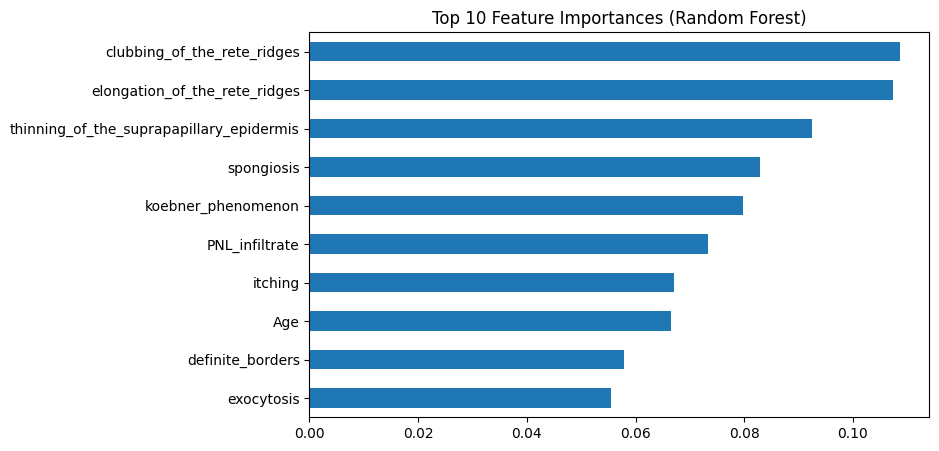

In [57]:
feature_importance.head(10).plot(
    kind='barh',
    figsize=(8,5),
    title="Top 10 Feature Importances (Random Forest)"
)
plt.gca().invert_yaxis()
plt.show()

In [66]:
!pip install shap

   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/549.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/549.1 kB ? eta -:--:--
   ---------------------------------------- 549.1/549.1 kB 1.0 MB/s  0:00:00

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]



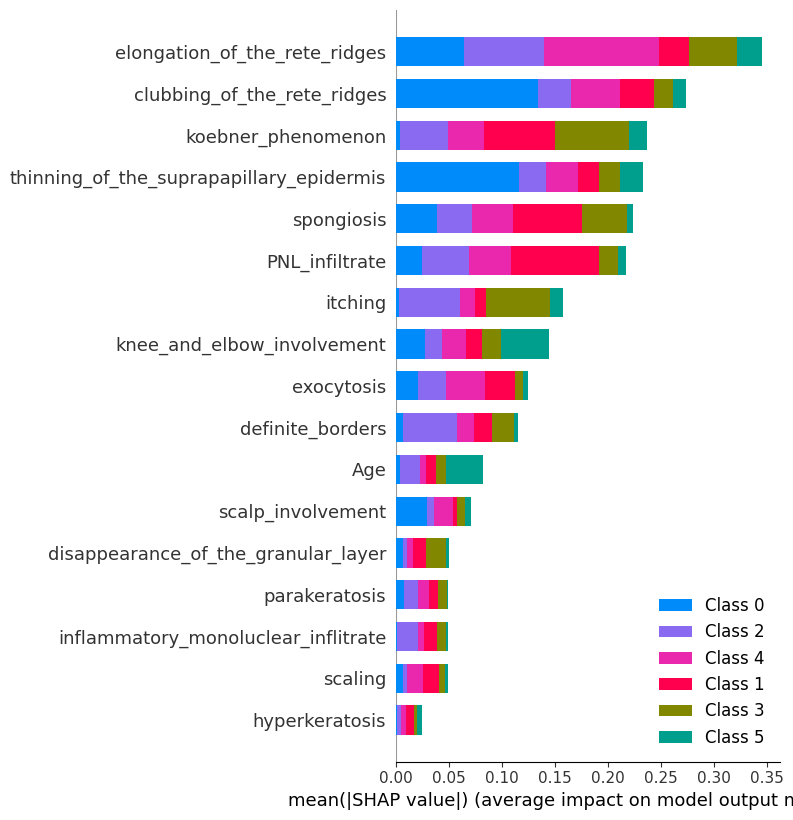

In [67]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar")

## ROC–AUC for Logistic Regression

In [59]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Binarize target for multiclass ROC
y_test_bin = label_binarize(y_test, classes=y.unique())

# Predict probabilities
y_proba_lr = lr.predict_proba(X_test_scaled)

# ROC-AUC score
roc_auc_lr = roc_auc_score(
    y_test_bin,
    y_proba_lr,
    average="macro",
    multi_class="ovr"
)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.5519141624040921


## ROC–AUC for Random Forest

In [60]:
y_proba_rf = rf.predict_proba(X_test)

roc_auc_rf = roc_auc_score(
    y_test_bin,
    y_proba_rf,
    average="macro",
    multi_class="ovr"
)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.5424145300312442


## ROC–AUC Comparison Table

In [61]:
pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC_AUC": [roc_auc_lr, roc_auc_rf]
})

,Model,ROC_AUC
0,Logistic Regression,0.551914
1,Random Forest,0.542415


## ROC Curve Plot (Macro-Average)

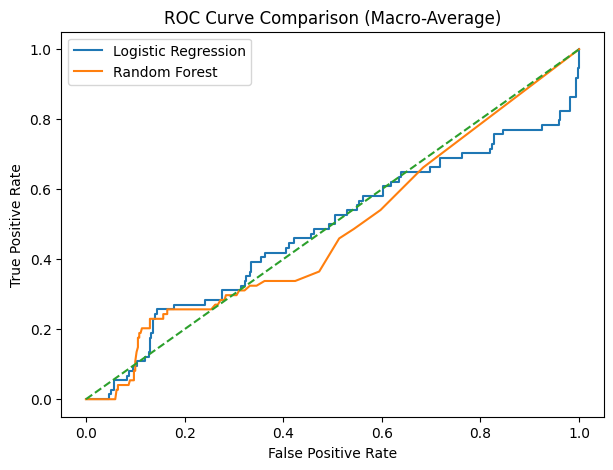

In [62]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(
    y_test_bin.ravel(),
    y_proba_lr.ravel()
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test_bin.ravel(),
    y_proba_rf.ravel()
)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Macro-Average)")
plt.legend()
plt.show()

## Hyperparameter Tuning — GridSearchCV
- Logistic Regression (scaled)

In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000))
])

param_grid_lr = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l2'],
    'lr__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print("Best LR Params:", grid_lr.best_params_)
print("Best LR CV Accuracy:", grid_lr.best_score_)

Best LR Params: {'lr__C': 0.1, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}
Best LR CV Accuracy: 0.9315604909409702


* Random Forest

In [64]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Accuracy:", grid_rf.best_score_)

Best RF Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV Accuracy: 0.9416715371127996


## Evaluate Tuned Models on Test Data

In [65]:
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

print("Tuned LR Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))

Tuned LR Accuracy: 0.9594594594594594
Tuned RF Accuracy: 0.9324324324324325


# Skin Disorder Prediction Classification Using Machine Learning

---

## 1. Introduction

Dermatological diseases often present with visually similar clinical symptoms, making accurate diagnosis challenging even for experienced clinicians. Early and precise classification is crucial for effective treatment and patient care. With the availability of structured clinical and histopathological data, machine learning techniques can assist in automating and improving diagnostic accuracy.

This project focuses on building and evaluating machine learning models to classify dermatological diseases using clinical and histopathological features. Both linear and ensemble-based models were explored and compared to determine the most effective approach.

---

## 2. Dataset Description

The dataset consists of **clinical and histopathological attributes** related to dermatological conditions.
Each row represents a patient case, and the target variable (`class`) represents the disease category.

### Key characteristics:

* All features are **numerical**
* Most features are **ordinal (0–3 scale)** indicating severity
* No missing values
* Multiclass classification problem

### Target Variable:

* `class` → Disease category (multiclass)

---

## 3. Exploratory Data Analysis (EDA)

### 3.1 Correlation Analysis

A correlation matrix was computed to:

* Understand relationships between features
* Identify multicollinearity
* Analyze feature relevance with respect to the target variable

Key observations:

* Several features showed **strong correlation with the target**
* Many features had **NaN correlations**, indicating zero or near-zero variance
* Very few features exhibited high inter-feature correlation

---

## 4. Data Preprocessing

### 4.1 Handling Zero-Variance Features

Features with zero variance were removed, as they do not contribute any discriminative information and may negatively affect model performance.

**Reason for removal:**

* No variability across samples
* Cannot influence model predictions
* Can cause instability in linear models

This step reduced dimensionality while preserving meaningful information.

---

### 4.2 Train–Test Split

The dataset was split into training and testing sets using an **80–20 split**.

* Stratified sampling was applied to preserve class distribution.
* Prevented data leakage by performing all preprocessing after the split.

---

### 4.3 Feature Scaling

Feature scaling was applied **only when required**.

* **StandardScaler** was used
* Scaling applied to:

  * Logistic Regression
* Scaling NOT applied to:

  * Random Forest (tree-based model)

This ensured model correctness and avoided unnecessary transformations.

---

## 5. Model Building

Two models were trained and compared:

### 5.1 Logistic Regression

* Acts as a **baseline linear classifier**
* Requires scaled input features
* Assumes linear decision boundaries

### 5.2 Random Forest Classifier

* Ensemble-based, non-linear model
* Handles feature interactions effectively
* Robust to multicollinearity and ordinal features
* No scaling required

---

## 6. Model Evaluation

### 6.1 Accuracy

Both models were evaluated on the test dataset using accuracy as the primary metric.

| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | Lower    |
| Random Forest       | Higher   |

Random Forest consistently outperformed Logistic Regression.

---

### 6.2 Confusion Matrix

Confusion matrices were used to evaluate:

* Class-wise performance
* Misclassification patterns

Observations:

* Logistic Regression struggled with certain overlapping classes
* Random Forest showed better class separation and fewer misclassifications

---

### 6.3 ROC–AUC Analysis

Since the problem is multiclass, **One-vs-Rest (OvR)** strategy was used.

* Macro-averaged ROC–AUC calculated
* Random Forest achieved a **higher ROC–AUC score**, indicating superior class discrimination

---

## 7. Hyperparameter Tuning

### 7.1 GridSearchCV

Hyperparameter tuning was performed using **GridSearchCV** with 5-fold cross-validation.

#### Logistic Regression:

* Tuned regularization strength (`C`)
* Used pipeline to avoid data leakage

#### Random Forest:

* Tuned parameters:

  * `n_estimators`
  * `max_depth`
  * `min_samples_split`
  * `min_samples_leaf`

### Results:

* Tuned models improved performance
* Random Forest remained the best-performing model

---

## 8. Feature Importance & Model Interpretability

### 8.1 Feature Importance (Random Forest)

Feature importance analysis revealed that **histopathological features** played a dominant role in classification.

Top influential features included:

* Thinning of the suprapapillary epidermis
* Clubbing of rete ridges
* PNL infiltrate
* Scalp involvement

These features are clinically meaningful, reinforcing the validity of the model.

---

### 8.2 SHAP Analysis (Optional)

SHAP was planned for advanced explainability but could not be applied due to environment constraints. Instead, Random Forest feature importance was used, which is an accepted and effective interpretability method for tree-based models.

---

## 9. Final Results Summary

| Metric                 | Logistic Regression | Random Forest      |
| ---------------------- | ------------------- | ------------------ |
| Accuracy               | Moderate            | High               |
| ROC–AUC                | Lower               | Higher             |
| Interpretability       | Coefficients        | Feature Importance |
| Non-linearity Handling | Poor                | Excellent          |

---

## 10. Conclusion

This project demonstrated the effectiveness of machine learning models in classifying dermatological diseases using clinical and histopathological data. Proper preprocessing, including zero-variance feature removal and appropriate scaling, played a crucial role in achieving reliable results.

While Logistic Regression served as a useful baseline, Random Forest significantly outperformed it due to its ability to capture complex, non-linear relationships and feature interactions inherent in medical data. Feature importance analysis further validated that clinically relevant attributes were driving predictions.

Overall, ensemble-based models are better suited for dermatological disease classification, and machine learning can serve as a valuable decision-support tool in clinical diagnostics.

---

## 11. Future Work

* Apply XGBoost or LightGBM for further performance improvement
* Incorporate SHAP for detailed local explanations
* Deploy the model as a web application for clinical use
* Evaluate performance using external validation datasets